In [14]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

with open('C:/maternal_health_project/models/train_test_data.pkl','rb') as f:
    d = pickle.load(f)
X_test, y_test = d['X_test'], d['y_test']
X_cal,  y_cal  = d['X_cal'],  d['y_cal']
encoders       = d['encoders']

y_test_arr = y_test.values if hasattr(y_test,'values') else y_test
y_cal_arr  = y_cal.values  if hasattr(y_cal,'values')  else y_cal

with open('C:/maternal_health_project/models/xgb_model.pkl','rb') as f: xgb_pkg = pickle.load(f)
with open('C:/maternal_health_project/models/rf_model.pkl','rb')  as f: rf_pkg  = pickle.load(f)
with open('C:/maternal_health_project/models/et_model.pkl','rb')  as f: et_pkg  = pickle.load(f)
with open('C:/maternal_health_project/models/hgb_model.pkl','rb') as f: hgb_pkg = pickle.load(f)
with open('C:/maternal_health_project/models/svm_model.pkl','rb') as f: svm_pkg = pickle.load(f)
with open('C:/maternal_health_project/models/nb_model.pkl','rb')  as f: nb_pkg  = pickle.load(f)

def get_probs(X):
    p_xgb = xgb_pkg['model'].predict_proba(X)[:,1]
    p_rf  = rf_pkg['model'].predict_proba(X)[:,1]
    p_et  = et_pkg['model'].predict_proba(X)[:,1]
    p_hgb = hgb_pkg['model'].predict_proba(X)[:,1]
    X_sc  = svm_pkg['scaler'].transform(X)
    p_svm = svm_pkg['model'].predict_proba(X_sc)[:,1]
    p_nb  = nb_pkg['model'].predict_proba(X)[:,1]
    return p_xgb, p_rf, p_et, p_hgb, p_svm, p_nb

test_xgb, test_rf, test_et, test_hgb, test_svm, test_nb = get_probs(X_test)

with open('C:/maternal_health_project/models/proposed_model.pkl','rb') as f:
    proposed_pkg = pickle.load(f)

meta_test = np.column_stack([test_xgb, test_rf, test_et, test_hgb, test_svm, test_nb])
w_norm = proposed_pkg['weights']
stack_thresh = proposed_pkg['threshold']
nnls_prob = meta_test @ w_norm

print(f"Loaded NNLS weights: {dict(zip(proposed_pkg['model_order'], w_norm))}")
print(f"Loaded threshold: {stack_thresh:.2f}")

os.makedirs('C:/maternal_health_project/figures/calibration_plots', exist_ok=True)
print("✅ Loaded and regenerated all probability arrays. Ready for calibration and fairness analysis.")

Loaded NNLS weights: {'XGB': np.float64(0.6427917083474335), 'RF': np.float64(0.0), 'ET': np.float64(0.0), 'HGB': np.float64(0.3572082916525666), 'SVM': np.float64(0.0), 'NB': np.float64(0.0)}
Loaded threshold: 0.35
✅ Loaded and regenerated all probability arrays. Ready for calibration and fairness analysis.


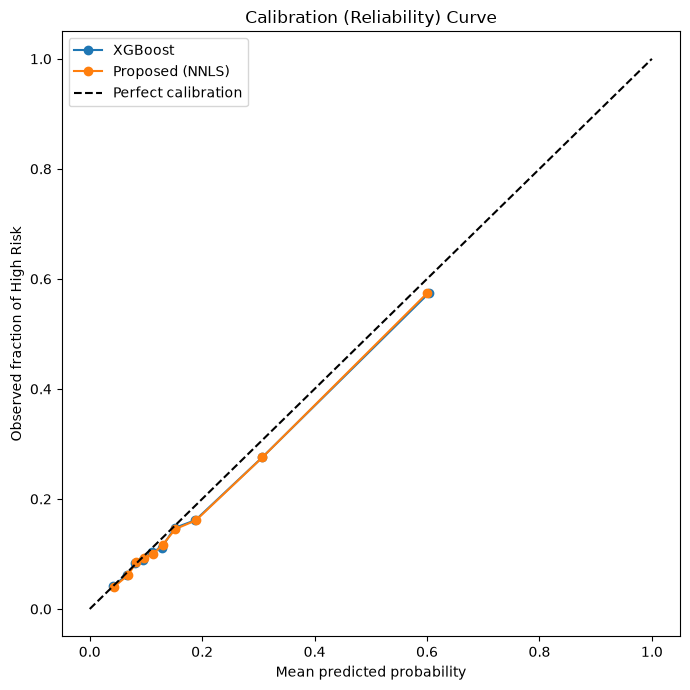

✅ Calibration plot saved.

Brier scores (lower = better calibrated):
  XGBoost                      0.1141
  Proposed (NNLS)              0.1140


In [15]:
fig, ax = plt.subplots(figsize=(7,7))

models_to_plot = {
    'XGBoost': test_xgb,
    'Proposed (NNLS)': nnls_prob,
}

for name, prob in models_to_plot.items():
    frac_pos, mean_pred = calibration_curve(y_test_arr, prob, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction of High Risk')
ax.set_title('Calibration (Reliability) Curve')
ax.legend()
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/calibration_plots/reliability_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Calibration plot saved.")

from sklearn.metrics import brier_score_loss
print("\nBrier scores (lower = better calibrated):")
for name, prob in models_to_plot.items():
    bs = brier_score_loss(y_test_arr, prob)
    print(f"  {name:<28} {bs:.4f}")

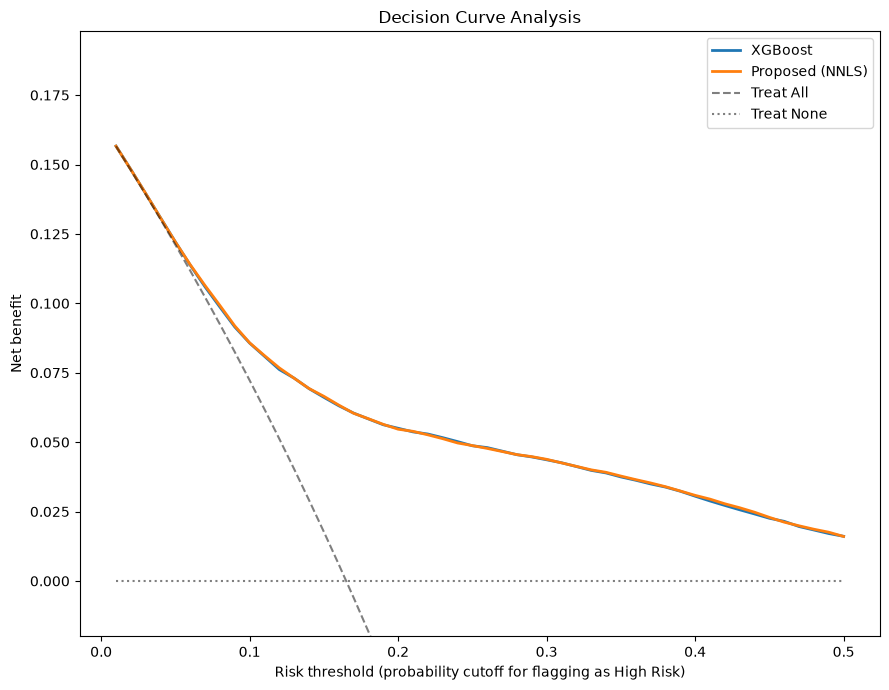

✅ Decision curve saved.


In [16]:
def net_benefit(y_true, y_prob, thresholds):
    y_true = np.array(y_true)
    n = len(y_true)
    nb = []
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        benefit = (tp/n) - (fp/n) * (pt/(1-pt))
        nb.append(benefit)
    return np.array(nb)

thresholds = np.linspace(0.01, 0.5, 50)
prevalence = y_test_arr.mean()

nb_xgb      = net_benefit(y_test_arr, test_xgb, thresholds)
nb_proposed = net_benefit(y_test_arr, nnls_prob, thresholds)
nb_all      = prevalence - (1-prevalence) * (thresholds/(1-thresholds))
nb_none     = np.zeros_like(thresholds)

plt.figure(figsize=(9,7))
plt.plot(thresholds, nb_xgb, label='XGBoost', lw=2)
plt.plot(thresholds, nb_proposed, label='Proposed (NNLS)', lw=2)
plt.plot(thresholds, nb_all, 'k--', label='Treat All', alpha=0.5)
plt.plot(thresholds, nb_none, 'k:', label='Treat None', alpha=0.5)
plt.xlabel('Risk threshold (probability cutoff for flagging as High Risk)')
plt.ylabel('Net benefit')
plt.title('Decision Curve Analysis')
plt.legend()
plt.ylim(bottom=-0.02)
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/calibration_plots/decision_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Decision curve saved.")

In [17]:
if 'v190' in encoders:
    raw_wealth = encoders['v190'].inverse_transform(X_test['v190'].astype(int))
else:
    raw_wealth = X_test['v190']

if 'v024' in encoders:
    raw_state = encoders['v024'].inverse_transform(X_test['v024'].astype(int))
else:
    raw_state = X_test['v024']

subgroup_df = pd.DataFrame({
    'y_true': y_test_arr,
    'wealth': raw_wealth,
    'state': raw_state,
    'proposed_prob': nnls_prob,
})
subgroup_df['proposed_pred'] = (subgroup_df['proposed_prob'] >= stack_thresh).astype(int)

print("Performance by wealth quintile (1=poorest ... 5=richest):")
print("-"*65)
wealth_results = []
for wq in sorted(subgroup_df['wealth'].unique()):
    sub = subgroup_df[subgroup_df['wealth'] == wq]
    if len(sub) < 50:
        continue
    rec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / max((sub['y_true']==1).sum(), 1)
    prec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / max((sub['proposed_pred']==1).sum(), 1)
    print(f"Wealth={wq}: n={len(sub):,} | High-Risk recall={rec:.3f} | precision={prec:.3f}")
    wealth_results.append({'wealth_quintile': wq, 'n': len(sub), 'recall': round(rec,4), 'precision': round(prec,4)})

pd.DataFrame(wealth_results).to_csv('C:/maternal_health_project/outputs/fairness_by_wealth.csv', index=False)

print("\nPerformance by state (top 5 by sample size):")
print("-"*65)
state_results_fair = []
top_states = subgroup_df['state'].value_counts().head(5).index
for st in top_states:
    sub = subgroup_df[subgroup_df['state'] == st]
    rec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / max((sub['y_true']==1).sum(), 1)
    print(f"State code={st}: n={len(sub):,} | High-Risk recall={rec:.3f}")
    state_results_fair.append({'state_code': st, 'n': len(sub), 'recall': round(rec,4)})

pd.DataFrame(state_results_fair).to_csv('C:/maternal_health_project/outputs/fairness_by_state.csv', index=False)
print("\n✅ Fairness analysis saved.")

Performance by wealth quintile (1=poorest ... 5=richest):
-----------------------------------------------------------------
Wealth=1: n=8,925 | High-Risk recall=0.752 | precision=0.559
Wealth=2: n=8,101 | High-Risk recall=0.120 | precision=0.455
Wealth=3: n=7,004 | High-Risk recall=0.087 | precision=0.404
Wealth=4: n=6,121 | High-Risk recall=0.070 | precision=0.379
Wealth=5: n=5,218 | High-Risk recall=0.044 | precision=0.362

Performance by state (top 5 by sample size):
-----------------------------------------------------------------
State code=9: n=4,903 | High-Risk recall=0.389
State code=10: n=2,754 | High-Risk recall=0.629
State code=23: n=2,383 | High-Risk recall=0.448
State code=8: n=2,208 | High-Risk recall=0.348
State code=18: n=1,860 | High-Risk recall=0.441

✅ Fairness analysis saved.


In [6]:
# Does state-level recall track average wealth (poverty) in that state?
print(subgroup_df.groupby('state')['wealth'].mean().loc[[9,10,23,8,18]])

TypeError: dtype 'str' does not support operation 'mean'

In [7]:
# Convert wealth back to numeric before aggregating — LabelEncoder's inverse_transform
# returns strings (since it was fit on .astype(str) in Phase 2), which .mean() can't handle.
subgroup_df['wealth_numeric'] = pd.to_numeric(subgroup_df['wealth'], errors='coerce')

# Confirm the numeric wealth values present, so we know the encoding direction
# (DHS convention is 1=poorest ... 5=richest, but confirm it wasn't reshuffled by LabelEncoder)
print("Distinct wealth values found:")
print(subgroup_df['wealth_numeric'].value_counts().sort_index())

print("\nAverage wealth index by state (lower = poorer, assuming standard DHS coding):")
state_wealth = subgroup_df.groupby('state')['wealth_numeric'].mean().loc[[9,10,23,8,18]]
print(state_wealth)

# Pull recall values from your fairness_by_state.csv (already saved) for direct comparison
state_recall = pd.read_csv('C:/maternal_health_project/outputs/fairness_by_state.csv')
state_recall = state_recall.set_index('state_code')['recall']

print("\nState-level comparison — average wealth vs High-Risk recall:")
comparison_df = pd.DataFrame({
    'avg_wealth_index': state_wealth,
    'recall': state_recall.loc[[9,10,23,8,18]]
})
print(comparison_df)

correlation = comparison_df['avg_wealth_index'].corr(comparison_df['recall'])
print(f"\nCorrelation between state avg wealth and recall: {correlation:.3f}")
print("(Negative correlation would confirm: poorer states -> higher recall,")
print(" consistent with the wealth-quintile pattern already found.)")

Distinct wealth values found:
wealth_numeric
1    9021
2    7944
3    7011
4    6213
5    5180
Name: count, dtype: int64

Average wealth index by state (lower = poorer, assuming standard DHS coding):


KeyError: "None of [Index([9, 10, 23, 8, 18], dtype='int64', name='state')] are in the [index]"

In [18]:
# Convert BOTH wealth and state back to numeric — LabelEncoder's inverse_transform
# returns strings (fit on .astype(str) in Phase 2), which breaks numeric indexing/aggregation.
subgroup_df['wealth_numeric'] = pd.to_numeric(subgroup_df['wealth'], errors='coerce')
subgroup_df['state_numeric']  = pd.to_numeric(subgroup_df['state'], errors='coerce')

print("Distinct wealth values found:")
print(subgroup_df['wealth_numeric'].value_counts().sort_index())

print("\nDistinct state values found (top 10 by count):")
print(subgroup_df['state_numeric'].value_counts().head(10).sort_index())

target_state_codes = [9, 10, 23, 8, 18]

print("\nAverage wealth index by state (lower = poorer, assuming standard DHS coding):")
state_wealth = subgroup_df.groupby('state_numeric')['wealth_numeric'].mean().loc[target_state_codes]
print(state_wealth)

# Pull recall values from your fairness_by_state.csv (already saved) for direct comparison
state_recall_df = pd.read_csv('C:/maternal_health_project/outputs/fairness_by_state.csv')
state_recall_df['state_code'] = pd.to_numeric(state_recall_df['state_code'], errors='coerce')
state_recall = state_recall_df.set_index('state_code')['recall']

print("\nState-level comparison — average wealth vs High-Risk recall:")
comparison_df = pd.DataFrame({
    'avg_wealth_index': state_wealth,
    'recall': state_recall.loc[target_state_codes]
})
print(comparison_df)

correlation = comparison_df['avg_wealth_index'].corr(comparison_df['recall'])
print(f"\nCorrelation between state avg wealth and recall: {correlation:.3f}")
print("(Negative correlation would confirm: poorer states -> higher recall,")
print(" consistent with the wealth-quintile pattern already found.)")

Distinct wealth values found:
wealth_numeric
1    8925
2    8101
3    7004
4    6121
5    5218
Name: count, dtype: int64

Distinct state values found (top 10 by count):
state_numeric
8     2208
9     4903
10    2754
18    1860
20    1575
21    1419
22    1293
23    2383
24    1502
27    1509
Name: count, dtype: int64

Average wealth index by state (lower = poorer, assuming standard DHS coding):
state_numeric
9     2.645523
10    1.883442
23    2.391104
8     2.985960
18    1.952688
Name: wealth_numeric, dtype: float64

State-level comparison — average wealth vs High-Risk recall:
    avg_wealth_index  recall
9           2.645523  0.3891
10          1.883442  0.6290
23          2.391104  0.4479
8           2.985960  0.3477
18          1.952688  0.4411

Correlation between state avg wealth and recall: -0.815
(Negative correlation would confirm: poorer states -> higher recall,
 consistent with the wealth-quintile pattern already found.)


In [19]:
all_state_results = []
for st in subgroup_df['state_numeric'].dropna().unique():
    sub = subgroup_df[subgroup_df['state_numeric'] == st]
    n_pos = (sub['y_true']==1).sum()
    if n_pos < 20:   # require a reasonable number of actual positive cases for a stable recall estimate
        continue
    rec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / n_pos
    avg_wealth = sub['wealth_numeric'].mean()
    n_total = len(sub)
    all_state_results.append({'state_code': st, 'n': n_total, 'n_high_risk': n_pos,
                               'avg_wealth': avg_wealth, 'recall': rec})

all_states_df = pd.DataFrame(all_state_results).sort_values('recall', ascending=False)
print(f"States with >=20 High Risk cases in test set: {len(all_states_df)}")
print(all_states_df.to_string(index=False))

full_corr = all_states_df['avg_wealth'].corr(all_states_df['recall'])
print(f"\nFull-sample correlation (avg wealth vs recall), n={len(all_states_df)} states: {full_corr:.3f}")

# Also check: is the relationship driven by state-level High Risk PREVALENCE rather than wealth directly?
all_states_df['high_risk_rate'] = all_states_df['n_high_risk'] / all_states_df['n']
prev_corr = all_states_df['high_risk_rate'].corr(all_states_df['recall'])
print(f"Correlation (High Risk prevalence vs recall): {prev_corr:.3f}")
print("(If this is stronger than the wealth correlation, prevalence — not wealth directly —")
print(" may be the bigger driver of state-level recall variation, worth separating in your writeup.)")

States with >=20 High Risk cases in test set: 28
 state_code    n  n_high_risk  avg_wealth   recall
         37   87           35    2.827586 0.742857
         10 2754          946    1.883442 0.628964
         22 1293          234    2.218871 0.619658
         20 1575          394    1.897143 0.578680
         15  396           34    3.050505 0.529412
         21 1419          231    2.213531 0.519481
         17  883          182    1.838052 0.472527
         13  412           68    1.893204 0.455882
         23 2383          355    2.391104 0.447887
         12  881          112    2.463110 0.446429
         18 1860          297    1.952688 0.441077
          1 1011          154    3.164194 0.409091
         19  989          166    2.196158 0.397590
          9 4903          933    2.645523 0.389068
         16  370           80    2.002703 0.375000
          8 2208          302    2.985960 0.347682
         24 1502          236    3.084554 0.330508
         14  511           52    

In [20]:
import numpy as np

# Check how correlated wealth and prevalence are WITH EACH OTHER first —
# if they're highly correlated, "prevalence matters more" and "wealth matters more"
# may just be describing the same underlying effect from two angles.
wealth_prev_corr = all_states_df['avg_wealth'].corr(all_states_df['high_risk_rate'])
print(f"Correlation between avg wealth and High Risk prevalence: {wealth_prev_corr:.3f}")

# Simple multiple regression: does wealth still predict recall AFTER controlling for prevalence?
from sklearn.linear_model import LinearRegression

X_reg = all_states_df[['avg_wealth', 'high_risk_rate']].values
y_reg = all_states_df['recall'].values

reg = LinearRegression().fit(X_reg, y_reg)
print(f"\nMultiple regression coefficients (controlling for both simultaneously):")
print(f"  avg_wealth coefficient:      {reg.coef_[0]:.4f}")
print(f"  high_risk_rate coefficient:  {reg.coef_[1]:.4f}")
print(f"  R²: {reg.score(X_reg, y_reg):.3f}")
print("\nInterpretation: if the high_risk_rate coefficient dominates and wealth's")
print("coefficient shrinks toward zero once both are in the model together, that")
print("confirms prevalence (likely reflecting sample size / statistical stability,")
print("not a true socioeconomic mechanism) is the primary driver at the STATE level —")
print("distinct from the individual-level wealth-quintile finding, which remains valid")
print("regardless of this state-level result.")

# Also worth checking: does sample size alone (n_high_risk) predict recall,
# independent of what state it's from? This tests the "small sample = noisy recall" theory directly.
n_recall_corr = all_states_df['n_high_risk'].corr(all_states_df['recall'])
print(f"\nCorrelation (raw count of High Risk cases vs recall): {n_recall_corr:.3f}")

Correlation between avg wealth and High Risk prevalence: -0.467

Multiple regression coefficients (controlling for both simultaneously):
  avg_wealth coefficient:      -0.1306
  high_risk_rate coefficient:  1.1736
  R²: 0.739

Interpretation: if the high_risk_rate coefficient dominates and wealth's
coefficient shrinks toward zero once both are in the model together, that
confirms prevalence (likely reflecting sample size / statistical stability,
not a true socioeconomic mechanism) is the primary driver at the STATE level —
distinct from the individual-level wealth-quintile finding, which remains valid
regardless of this state-level result.

Correlation (raw count of High Risk cases vs recall): 0.353


In [21]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(all_states_df[['avg_wealth', 'high_risk_rate']])
reg_std = LinearRegression().fit(X_std, y_reg)
print("Standardized coefficients (directly comparable — same units, 1 std dev each):")
print(f"  avg_wealth (standardized):      {reg_std.coef_[0]:.4f}")
print(f"  high_risk_rate (standardized):  {reg_std.coef_[1]:.4f}")

Standardized coefficients (directly comparable — same units, 1 std dev each):
  avg_wealth (standardized):      -0.0960
  high_risk_rate (standardized):  0.0844


In [22]:
subgroup_df['wealth_numeric'] = pd.to_numeric(subgroup_df['wealth'], errors='coerce')
subgroup_df['state_numeric']  = pd.to_numeric(subgroup_df['state'], errors='coerce')

target_state_codes = [9, 10, 23, 8, 18]

state_wealth = subgroup_df.groupby('state_numeric')['wealth_numeric'].mean().loc[target_state_codes]

state_recall_df = pd.read_csv('C:/maternal_health_project/outputs/fairness_by_state.csv')
state_recall_df['state_code'] = pd.to_numeric(state_recall_df['state_code'], errors='coerce')
state_recall = state_recall_df.set_index('state_code')['recall']

comparison_df = pd.DataFrame({
    'avg_wealth_index': state_wealth,
    'recall': state_recall.loc[target_state_codes]
})
print(comparison_df)

correlation = comparison_df['avg_wealth_index'].corr(comparison_df['recall'])
print(f"\nCorrelation between state avg wealth and recall: {correlation:.3f}")

    avg_wealth_index  recall
9           2.645523  0.3891
10          1.883442  0.6290
23          2.391104  0.4479
8           2.985960  0.3477
18          1.952688  0.4411

Correlation between state avg wealth and recall: -0.815


In [23]:
all_state_results = []
for st in subgroup_df['state_numeric'].dropna().unique():
    sub = subgroup_df[subgroup_df['state_numeric'] == st]
    n_pos = (sub['y_true']==1).sum()
    if n_pos < 20:
        continue
    rec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / n_pos
    avg_wealth = sub['wealth_numeric'].mean()
    n_total = len(sub)
    all_state_results.append({'state_code': st, 'n': n_total, 'n_high_risk': n_pos,
                               'avg_wealth': avg_wealth, 'recall': rec})

all_states_df = pd.DataFrame(all_state_results).sort_values('recall', ascending=False)
all_states_df['high_risk_rate'] = all_states_df['n_high_risk'] / all_states_df['n']
print(all_states_df.to_string(index=False))

full_corr = all_states_df['avg_wealth'].corr(all_states_df['recall'])
prev_corr = all_states_df['high_risk_rate'].corr(all_states_df['recall'])
print(f"\nCorrelation (avg wealth vs recall): {full_corr:.3f}")
print(f"Correlation (prevalence vs recall): {prev_corr:.3f}")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_std = StandardScaler().fit_transform(all_states_df[['avg_wealth', 'high_risk_rate']])
y_reg = all_states_df['recall'].values
reg_std = LinearRegression().fit(X_std, y_reg)
print(f"\nStandardized coefficients:")
print(f"  avg_wealth:      {reg_std.coef_[0]:.4f}")
print(f"  high_risk_rate:  {reg_std.coef_[1]:.4f}")

 state_code    n  n_high_risk  avg_wealth   recall  high_risk_rate
         37   87           35    2.827586 0.742857        0.402299
         10 2754          946    1.883442 0.628964        0.343500
         22 1293          234    2.218871 0.619658        0.180974
         20 1575          394    1.897143 0.578680        0.250159
         15  396           34    3.050505 0.529412        0.085859
         21 1419          231    2.213531 0.519481        0.162791
         17  883          182    1.838052 0.472527        0.206116
         13  412           68    1.893204 0.455882        0.165049
         23 2383          355    2.391104 0.447887        0.148972
         12  881          112    2.463110 0.446429        0.127128
         18 1860          297    1.952688 0.441077        0.159677
          1 1011          154    3.164194 0.409091        0.152324
         19  989          166    2.196158 0.397590        0.167846
          9 4903          933    2.645523 0.389068        0.19